In [16]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit
import time


F_m = 1
omega = 5
omegaF = 0.1

def exact_sol(t):
    A = F_m * 1/(omegaF**2 - omega**2)
    x = F_m * 1/(omega**2 - omegaF**2) * np.cos(omegaF*t) + A*np.cos(omega*t)
    v = -F_m * 1/(omega**2 - omegaF**2) * omegaF * np.sin(omegaF*t) - omega*A*np.sin(omega*t)
    
    return x, v


def L2_norm_cum(x_approx, x_exact, Nt):
    errs = np.zeros(x_approx.shape)
    
    diff_sq = (x_approx - x_exact)**2
    accum = np.cumsum(diff_sq)
    
    errs = np.sqrt( accum / range(1,Nt+1))
        
    return errs

def L2_norm(x_approx, x_exact, Nt):
    return np.sqrt( (x_approx - x_exact)**2 )


def forward_euler(t, dt):
    x = np.zeros(t.shape)
    v = np.zeros(t.shape)
    
    for n in range(len(t)-1):
        x[n+1] = x[n] + dt*v[n]
        v[n+1] = v[n] + dt*(-omega**2 * x[n] + F_m*np.cos(omegaF*t[n]))
    
    return x, v


def symplectic_euler(t, dt):
    x = np.zeros(t.shape)
    v = np.zeros(t.shape)
    
    for n in range(len(t)-1):
        v[n+1] = v[n] + dt*(-omega**2 * x[n] + F_m*np.cos(omegaF*t[n]))
        x[n+1] = x[n] + dt*v[n+1]
    
    return x, v
    

def rk4(t, dt):
    x = np.zeros(t.shape)
    v = np.zeros(t.shape)
    
    for n in range(len(t)-1):
        k1x = v[n]
        k1v = -omega**2 * x[n] + F_m*np.cos(omegaF*t[n])
        
        k2x = v[n] + k1v*dt/2
        k2v = -omega**2 * (x[n] + k1x*dt/2) + F_m*np.cos(omegaF*t[n])
        
        k3x = v[n] + k2v*dt/2
        k3v = -omega**2 * (x[n] + k2x*dt/2) + F_m*np.cos(omegaF*t[n])
        
        k4x = v[n] + k3v*dt
        k4v = -omega**2 * (x[n] + k3x*dt) + F_m*np.cos(omegaF*t[n])
        
        x[n+1] = x[n] + (k1x + 2*k2x + 2*k3x + k4x)*dt/6
        v[n+1] = v[n] + (k1v + 2*k2v + 2*k3v + k4v)*dt/6
    
    return x, v


###

tmin = 0
tmax = 100

Time of FE: 1.4738476276397705
Total L2: 0.004501205249689617


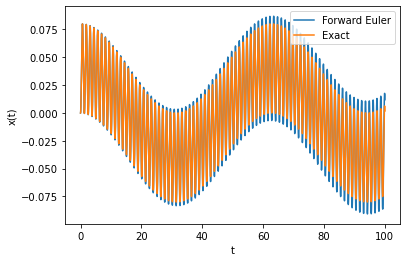

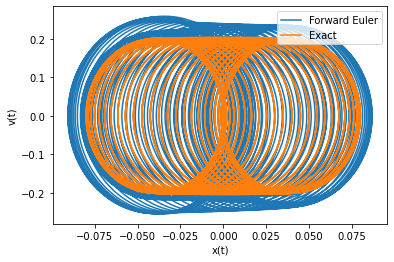

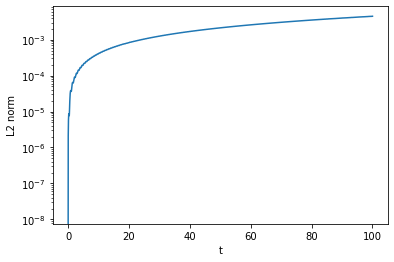

In [3]:
# FORWARD EULER

dt = 0.0002

t = np.arange(tmin, tmax, dt)
x_exact, v_exact = exact_sol(t)

s = time.time()
x_FE, v_FE = forward_euler(t,dt)
FE_dur = time.time() - s

print('Time of FE: ' + str(FE_dur))

# Response of system
plt.figure()
plt.plot(t, x_FE, label='Forward Euler')
plt.plot(t, x_exact, label='Exact')
plt.legend()
plt.xlabel('t')
plt.ylabel('x(t)')


# Phase portrait
plt.figure()
plt.plot(x_FE, v_FE, label='Forward Euler')
plt.plot(x_exact, v_exact, label='Exact')
plt.legend()
plt.xlabel('x(t)')
plt.ylabel('v(t)')


# Error evolution
errs_FE = L2_norm_cum(x_FE, x_exact, len(t))
print('Total L2: ' + str(errs_FE[-1]))

plt.figure()
plt.semilogy(t, errs_FE)
plt.xlabel('t')
plt.ylabel('L2 norm')

plt.show()

Time of SE: 0.28344225883483887
Total L2: 7.81566415977023e-05


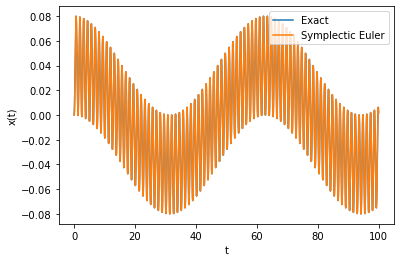

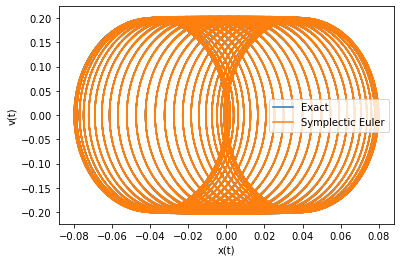

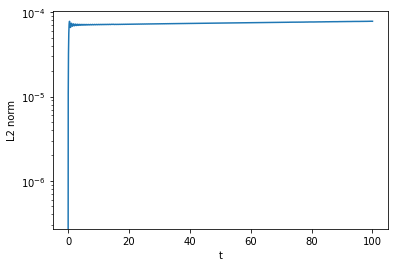

In [2]:
# SYMPLECTIC EULER

dt = 0.001

t = np.arange(tmin, tmax, dt)
x_exact, v_exact = exact_sol(t)

s = time.time()
x_SE, v_SE = symplectic_euler(t,dt)
SE_dur = time.time() - s

print('Time of SE: ' + str(SE_dur))

# Response of system
plt.figure()
plt.plot(t, x_exact, label='Exact')
plt.plot(t, x_SE, label='Symplectic Euler')
plt.legend()
plt.xlabel('t')
plt.ylabel('x(t)')


# Phase portrait
plt.figure()
plt.plot(x_exact, v_exact, label='Exact')
plt.plot(x_SE, v_SE, label='Symplectic Euler')
plt.legend()
plt.xlabel('x(t)')
plt.ylabel('v(t)')


# Error evolution
errs_SE = L2_norm_cum(x_SE, x_exact, len(t))
print('Total L2: ' + str(errs_SE[-1]))

plt.figure()
plt.semilogy(t, errs_SE)
plt.xlabel('t')
plt.ylabel('L2 norm')

plt.show()

Time of RK4: 1.2669966220855713
Total L2: 1.382453547420526e-06


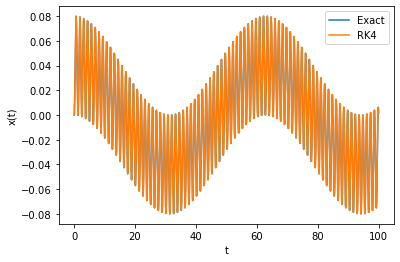

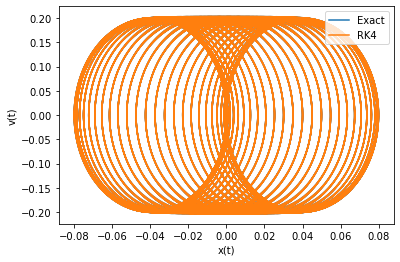

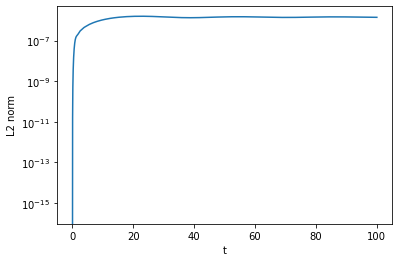

In [17]:
# RUNGE-KUTTA

dt = 0.001

t = np.arange(tmin, tmax, dt)
x_exact, v_exact = exact_sol(t)

s = time.time()
x_RK4, v_RK4 = rk4(t,dt)
RK_dur = time.time() - s

print('Time of RK4: ' + str(RK_dur))

# Response of system
plt.figure()
plt.plot(t, x_exact, label='Exact')
plt.plot(t, x_RK4, label='RK4')
plt.legend()
plt.xlabel('t')
plt.ylabel('x(t)')


# Phase portrait
plt.figure()
plt.plot(x_exact, v_exact, label='Exact')
plt.plot(x_RK4, v_RK4, label='RK4')
plt.legend()
plt.xlabel('x(t)')
plt.ylabel('v(t)')


# Error evolution
errs_RK4 = L2_norm_cum(x_RK4, x_exact, len(t))
print('Total L2: ' + str(errs_RK4[-1]))

plt.figure()
plt.semilogy(t, errs_RK4)
plt.xlabel('t')
plt.ylabel('L2 norm')

plt.show()

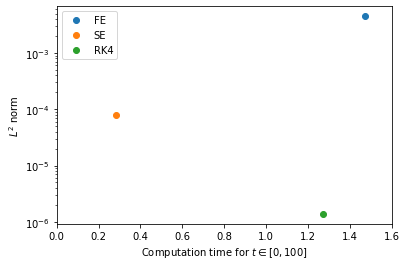

In [20]:
plt.figure()
plt.semilogy(1.4738,0.0045012,'o', label='FE')
plt.semilogy(0.28344,7.8156*1e-5,'o', label='SE')
plt.semilogy(1.2703,1.3824*1e-6,'o', label='RK4')
plt.legend()
plt.xlim([0,1.6])
plt.xlabel(r'Computation time for $t\in[0,100]$')
plt.ylabel(r'$L^2$ norm')

plt.show()